<a href="https://colab.research.google.com/github/jjlizcano/brain-stroke-segmentation/blob/main/brain_stroke_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
# 1. Instalación y actualización de librerías
!pip install -q --upgrade kagglehub nibabel matplotlib
import kagglehub
import os
import nibabel as nib
import matplotlib.pyplot as plt
import nibabel as nib
import matplotlib.pyplot as plt
import random

# 2. Clonar o actualizar el repositorio

REPO_URL = "https://github.com/jjlizcano/brain-stroke-segmentation.git"
REPO_DIR = "brain-stroke-segmentation"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    %cd {REPO_DIR}
    !git pull
    %cd ..

print("Repositorio listo en:", REPO_DIR)

Cloning into 'brain-stroke-segmentation'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 6 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.
Resolving deltas: 100% (1/1), done.
Repositorio listo en: brain-stroke-segmentation


# Importar dataset

In [17]:
path = kagglehub.dataset_download("orvile/isles-2022-brain-stoke-dataset")
print("Los archivos se descargaron en:", path)

Using Colab cache for faster access to the 'isles-2022-brain-stoke-dataset' dataset.
Los archivos se descargaron en: /kaggle/input/isles-2022-brain-stoke-dataset


# ¿Cuántas imágenes hay?

In [22]:
files = [] # Para almacenar las rutas de los archivos NIfTI
for root, dirs, filenames in os.walk(path): # Itera en el dataset
    for filename in filenames: # Para cada archivo encontrado en el directorio actual...
        if filename.endswith('.nii'): # Si el nombre del archivo termina con '.nii'...
            files.append(os.path.join(root, filename)) # Construye la ruta completa y la añade a 'files'.

print(f"Se encontraron {len(files)} archivos.")
for f in files[:5]: # Primeros 5 archivos encontrados
    print(f)

Se encontraron 1000 archivos.
/kaggle/input/isles-2022-brain-stoke-dataset/ISLES-2022/ISLES-2022/sub-strokecase0202/ses-0001/dwi/sub-strokecase0202_ses-0001_dwi.nii/dwi_skull-stripped.nii
/kaggle/input/isles-2022-brain-stoke-dataset/ISLES-2022/ISLES-2022/sub-strokecase0202/ses-0001/dwi/sub-strokecase0202_ses-0001_adc.nii/adc_skull-stripped.nii
/kaggle/input/isles-2022-brain-stoke-dataset/ISLES-2022/ISLES-2022/sub-strokecase0202/ses-0001/anat/sub-strokecase0202_ses-0001_FLAIR.nii
/kaggle/input/isles-2022-brain-stoke-dataset/ISLES-2022/ISLES-2022/sub-strokecase0242/ses-0001/dwi/sub-strokecase0242_ses-0001_adc.nii/sub-basilarstroke0076_ses-20200607_ornt-iso_skull-stripped_sequ-204_adc.nii
/kaggle/input/isles-2022-brain-stoke-dataset/ISLES-2022/ISLES-2022/sub-strokecase0242/ses-0001/dwi/sub-strokecase0242_ses-0001_dwi.nii/sub-basilarstroke0076_ses-20200607_ornt-iso_skull-stripped_sequ-203_dwi.nii


# Visualización de uno de los archivos

Imagen aleatoria: /kaggle/input/isles-2022-brain-stoke-dataset/ISLES-2022/ISLES-2022/sub-strokecase0158/ses-0001/anat/sub-strokecase0158_ses-0001_FLAIR.nii


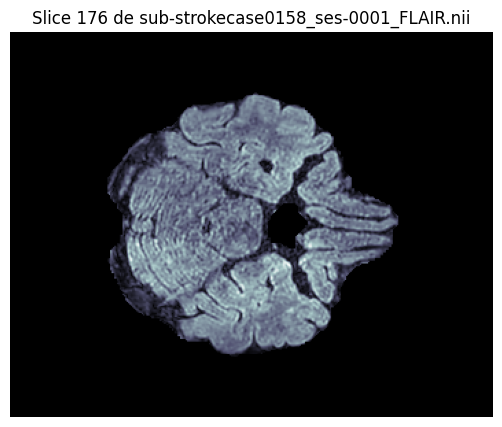

In [42]:
if len(files) > 0:
    test_path = random.choice(files)
    print(f"Imagen aleatoria: {test_path}")

    # Cargar datos
    data = nib.load(test_path).get_fdata()

    slice_idx = data.shape[2] // 2 # Rebanada central
    plt.figure(figsize=(10, 5))
    plt.imshow(data[:, :, slice_idx], cmap='bone') # 'bone' queda muy bien para MRI
    plt.title(f"Slice {slice_idx} de {os.path.basename(test_path)}")
    plt.axis('off')
    plt.show()
else:
    print("No se encontraron archivos NIfTI.")